# 07 — Trading Parameter Grid Search (Purged K-Fold / No Data Leakage)

## Why this notebook replaces `07_grid_search.ipynb`

The original grid search evaluated all parameter combinations on the **test set**, meaning:

1. The production LightGBM model had already been trained ignoring the test period.
2. But every grid iteration **observed test-set outcomes** to select trading parameters.
3. This introduces **indirect data leakage** — the best config is optimised specifically for the test distribution.

The result is overly optimistic reported performance that will not generalise.

## Purged K-Fold approach

We generate **Out-Of-Sample (OOS) probabilities** from the training set using Purged K-Fold CV:

| Concept | Detail |
|---|---|
| Folds | K=5 chronological folds of the training set |
| Embargo | 168 bars (~1 week of hourly data) removed on each side of every fold boundary |
| Fold model | LGBM trained on training data **excluding** the fold + embargo zones; early-stopped on `val_df` |
| OOS probs | Each fold model predicts on its held-out fold only |
| Coverage | ~57 k training bars (minus embargo regions) |

The grid search then runs on these OOS probs — **never touching the test set**.

The **final honest evaluation** applies the best parameters to the test set exactly once, using the production model (`local_models/lgbm_model.txt`).

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'

TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# Purged K-Fold settings
K       = 5    # number of folds
EMBARGO = 168  # bars to exclude around each fold boundary (~1 week at 1h)

# ── Optimisation ──────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 30
TOP_N           = 20

# ── LightGBM hyperparams (from notebook 06) ───────────────────────────────────
LGB_PARAMS = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'n_estimators':     1000,
    'learning_rate':    0.02,
    'num_leaves':       31,
    'max_depth':        -1,
    'min_child_samples': 50,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}
EARLY_STOPPING_ROUNDS = 50

# ── Search grid ───────────────────────────────────────────────────────────────
GRID = {
    'long_threshold':  [0.54, 0.55, 0.57, 0.59, 0.61],
    'short_threshold': [0.39, 0.41, 0.43, 0.45, 0.46],
    'atr_multiplier':  [1.5, 2.0, 2.5],
    'min_sl':          [0.010, 0.015, 0.020],
    'take_profit':     [0.025, 0.030, 0.040],
    'min_hold':        [4, 6, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}

In [2]:
# ── Imports & paths ───────────────────────────────────────────────────────────
import itertools
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()

FEATURES_DIR = REPO_ROOT / 'data' / 'features'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
FIGURES_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/figures/grid_lgbm


In [3]:
# ── Load data, split, build arrays ───────────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

# Load selected features from CSV produced in notebook 06
selected_features = pd.read_csv(
    MODELS_DIR / 'lgbm_features.csv', header=None
)[0].tolist()

X_train = train_df[selected_features].values
y_train = train_df['label'].values
X_val   = val_df[selected_features].values
y_val   = val_df['label'].values
X_test  = test_df[selected_features].values
y_test  = test_df['label'].values

print(f'Selected features : {len(selected_features)}')
print(f'Train : {X_train.shape}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val   : {X_val.shape}   {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test  : {X_test.shape}  {test_df.index.min().date()} → {test_df.index.max().date()}')

Selected features : 50
Train : (57230, 50)  2017-11-15 → 2024-06-01
Val   : (3888, 50)   2024-06-01 → 2024-11-10
Test  : (13248, 50)  2024-11-10 → 2026-05-16


## 1. Purged K-Fold OOS probability generation

In [4]:
# ── Purged K-Fold: generate OOS probs over the training set ───────────────────
# Each fold model is trained on all training data EXCEPT:
#   - the fold itself (fold_start : fold_end)
#   - an embargo of EMBARGO bars on each side of the fold boundary
# Early stopping uses the original val_df to keep signal consistent.

oos_probs = pd.Series(np.nan, index=train_df.index)
fold_size = len(train_df) // K

for k in range(K):
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else len(train_df)

    emb_start = max(0, fold_start - EMBARGO)
    emb_end   = min(len(train_df), fold_end + EMBARGO)

    # Training mask: exclude fold + embargo zones
    mask = np.ones(len(train_df), dtype=bool)
    mask[emb_start:emb_end] = False

    Xtr_k = X_train[mask]
    ytr_k = y_train[mask]

    # Predict only on the fold (not the embargo)
    X_fold   = X_train[fold_start:fold_end]
    fold_idx = train_df.index[fold_start:fold_end]

    ds_tr = lgb.Dataset(Xtr_k, label=ytr_k, feature_name=selected_features)
    ds_vl = lgb.Dataset(X_val, label=y_val, feature_name=selected_features, reference=ds_tr)

    fold_model = lgb.train(
        LGB_PARAMS, ds_tr,
        valid_sets=[ds_tr, ds_vl],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),  # silent
        ],
    )

    oos_probs.loc[fold_idx] = fold_model.predict(X_fold)
    print(
        f'Fold {k+1}/{K}: '
        f'train={mask.sum():,}  '
        f'fold={len(fold_idx):,}  '
        f'best_iter={fold_model.best_iteration}  '
        f'prob_range=[{oos_probs.loc[fold_idx].min():.3f}, '
        f'{oos_probs.loc[fold_idx].max():.3f}]'
    )
    del fold_model

print(f'\nOOS probs coverage: {oos_probs.notna().sum():,} / {len(oos_probs):,} training bars')

Fold 1/5: train=45,616  fold=11,446  best_iter=65  prob_range=[0.399, 0.635]
Fold 2/5: train=45,448  fold=11,446  best_iter=81  prob_range=[0.369, 0.667]
Fold 3/5: train=45,448  fold=11,446  best_iter=76  prob_range=[0.385, 0.648]
Fold 4/5: train=45,448  fold=11,446  best_iter=67  prob_range=[0.361, 0.664]
Fold 5/5: train=45,616  fold=11,446  best_iter=74  prob_range=[0.374, 0.639]

OOS probs coverage: 57,230 / 57,230 training bars


OOS probability statistics:
  Count : 57,230
  Mean  : 0.5111
  Std   : 0.0506
  Min   : 0.3609
  Max   : 0.6670
  p25   : 0.4735
  p50   : 0.5157
  p75   : 0.5472


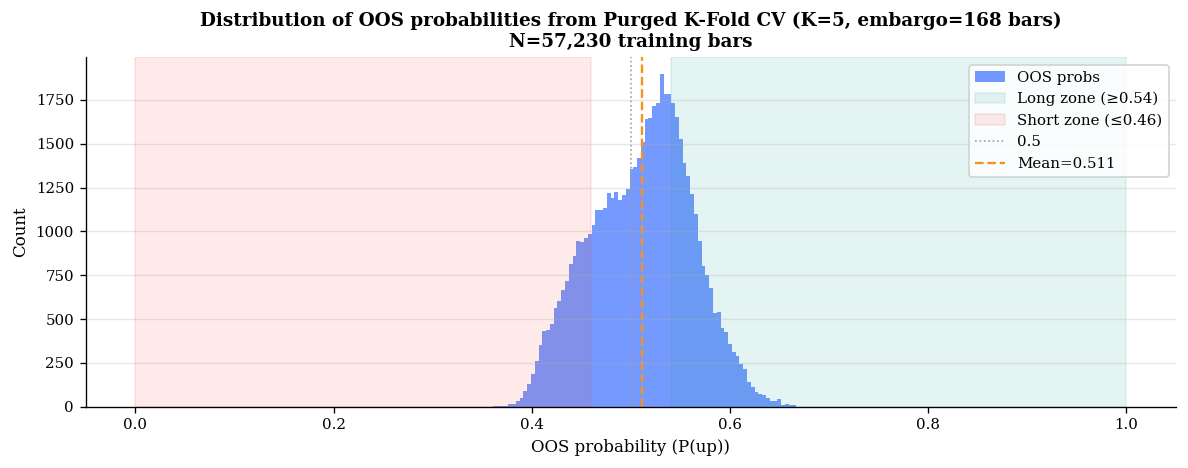

In [5]:
# ── OOS probability statistics & distribution plot ────────────────────────────
oos_valid = oos_probs.dropna()

print('OOS probability statistics:')
print(f'  Count : {len(oos_valid):,}')
print(f'  Mean  : {oos_valid.mean():.4f}')
print(f'  Std   : {oos_valid.std():.4f}')
print(f'  Min   : {oos_valid.min():.4f}')
print(f'  Max   : {oos_valid.max():.4f}')
print(f'  p25   : {oos_valid.quantile(0.25):.4f}')
print(f'  p50   : {oos_valid.median():.4f}')
print(f'  p75   : {oos_valid.quantile(0.75):.4f}')

# Distribution of OOS probs with threshold zones marked
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(oos_valid, bins=80, color=BLUE, alpha=0.65, edgecolor='none', label='OOS probs')

# Mark long and short threshold zones using the grid min/max values
long_thr_min  = min(GRID['long_threshold'])
short_thr_max = max(GRID['short_threshold'])

ymax = ax.get_ylim()[1]
ax.axvspan(long_thr_min, 1.0,  alpha=0.12, color=GREEN,  label=f'Long zone (≥{long_thr_min})')
ax.axvspan(0.0, short_thr_max, alpha=0.12, color=RED,    label=f'Short zone (≤{short_thr_max})')
ax.axvline(0.5, color=GREY, lw=1.0, ls=':', label='0.5')
ax.axvline(oos_valid.mean(), color=ACCENT, lw=1.4, ls='--',
           label=f'Mean={oos_valid.mean():.3f}')

ax.set_xlabel('OOS probability (P(up))')
ax.set_ylabel('Count')
ax.set_title(
    f'Distribution of OOS probabilities from Purged K-Fold CV '
    f'(K={K}, embargo={EMBARGO} bars)\n'
    f'N={len(oos_valid):,} training bars',
    fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_prob_distribution_vtrain.png')
plt.show()

## 2. Grid search on OOS probabilities

In [6]:
# ── Backtest engine ───────────────────────────────────────────────────────────
def run_backtest(probs, close_arr, atr_arr, sig_index, params):
    long_thr   = params['long_threshold']
    short_thr  = params['short_threshold']
    exit_long  = 1 - long_thr
    exit_short = 1 - short_thr
    atr_mult   = params['atr_multiplier']
    min_sl     = params['min_sl']
    tp         = params['take_profit']
    min_hold   = params['min_hold']
    max_hold   = params['max_hold']
    cooldown_n = params['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_ts = None; entry_cash = 0.0
    dynamic_sl = 0.0; hold_count = 0; cooldown = 0

    equity_curve = [1.0]
    trade_log    = []

    for ts, px, conf, atr_pct in zip(sig_index, close_arr, probs, atr_arr):
        if cooldown > 0:
            cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl = (px - entry_px) / entry_px if direction == 'long' \
                   else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:          reason = 'sl'
            elif pnl >= tp:                   reason = 'tp'
            elif hold_count >= max_hold:       reason = 'max_hold'
            elif hold_count >= min_hold:
                if direction == 'long'  and conf < exit_long:  reason = 'conf'
                elif direction == 'short' and conf > exit_short: reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0; cooldown = cooldown_n

        if not in_pos and cooldown == 0:
            sl = max(atr_mult * atr_pct, min_sl)
            if conf >= long_thr:
                units = cash / px; cash = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
            elif conf <= short_thr:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    # Force close
    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


def score(equity_arr, trades_df, metric):
    """Compute the optimisation metric for one backtest run."""
    if trades_df.empty:
        return -np.inf

    eq  = equity_arr
    ret = np.log(eq[1:] / (eq[:-1] + 1e-12))
    ann = 24 * 365

    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))

    elif metric == 'total_return':
        return float(eq[-1] - 1)

    elif metric == 'calmar':
        ann_ret = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ann_ret / (abs(mdd) + 1e-6)

    elif metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())

    elif metric == 'profit_factor':
        gains  = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        losses = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(gains / (losses + 1e-6))

    return -np.inf

In [7]:
# ── Build valid grid combos ───────────────────────────────────────────────────
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))

valid_combos = []
for vals in combos:
    p = dict(zip(keys, vals))
    # dead-band: long_thr and (1 - short_thr) must differ by at least 0.02
    if p['long_threshold'] - (1 - p['short_threshold']) < 0.02:
        continue
    # symmetric: short_threshold < 0.5 and long_threshold > 0.5
    if p['short_threshold'] >= 0.5 or p['long_threshold'] <= 0.5:
        continue
    valid_combos.append(p)

print(f'Total combinations : {len(combos):,}')
print(f'Valid after filter : {len(valid_combos):,}')
print(f'Optimising for     : {OPTIMISE_METRIC}')
print(f'Minimum trades     : {MIN_TRADES}')

Total combinations : 8,100
Valid after filter : 1,944
Optimising for     : sharpe
Minimum trades     : 30


In [8]:
# ── Grid search on OOS probs ──────────────────────────────────────────────────
# Drop NaN rows (embargo zones at fold boundaries) and re-align arrays
oos_mask   = oos_probs.notna().values
probs_oos  = oos_probs.values[oos_mask]
close_oos  = train_df['close'].values[oos_mask]
atr_oos    = train_df['atr_14_pct'].values[oos_mask]
index_oos  = train_df.index[oos_mask]

print(f'OOS bars used for grid search: {len(probs_oos):,}')
print(f'OOS prob range: [{probs_oos.min():.4f}, {probs_oos.max():.4f}]')

results = []

for params in tqdm(valid_combos, desc='Grid search (OOS)'):
    eq, tdf = run_backtest(probs_oos, close_oos, atr_oos, index_oos, params)

    n_trades = len(tdf)
    if n_trades < MIN_TRADES:
        continue

    s = score(eq, tdf, OPTIMISE_METRIC)

    pk   = np.maximum.accumulate(eq)
    mdd  = float(((eq - pk) / (pk + 1e-12)).min())
    ret  = np.log(eq[1:] / (eq[:-1] + 1e-12))
    shrp = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

    results.append({
        **params,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       shrp,
        'max_dd':       mdd,
        'n_trades':     n_trades,
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'avg_hold':     float(tdf['hold_h'].mean()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid results : {len(results_df):,}')
print(f'Best {OPTIMISE_METRIC}    : {results_df["score"].iloc[0]:.4f}')
print(f'Worst {OPTIMISE_METRIC}   : {results_df["score"].iloc[-1]:.4f}')

OOS bars used for grid search: 57,230
OOS prob range: [0.3609, 0.6670]


Grid search (OOS): 100%|██████████| 1944/1944 [00:55<00:00, 34.87it/s]


Valid results : 1,944
Best sharpe    : 1.7124
Worst sharpe   : 0.0100


In [9]:
# ── Leaderboard ───────────────────────────────────────────────────────────────
display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'long_threshold', 'short_threshold',
    'atr_multiplier', 'min_sl', 'take_profit',
    'min_hold', 'max_hold', 'cooldown',
]

top = results_df[display_cols].head(TOP_N).copy()
top['total_return'] = top['total_return'].map('{:+.2%}'.format)
top['max_dd']       = top['max_dd'].map('{:.2%}'.format)
top['win_rate']     = top['win_rate'].map('{:.1%}'.format)
top['score']        = top['score'].map('{:.4f}'.format)
top['sharpe']       = top['sharpe'].map('{:.3f}'.format)

print(f'Top {TOP_N} by {OPTIMISE_METRIC} (OOS training set):\n')
print(top.to_string(index=True))

best       = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'\n── Best OOS config ──────────────────────────────────────')
for k in keys:
    print(f'  {k:<22}: {best[k]}')
print(f'  {"score (" + OPTIMISE_METRIC + ")":<22}: {best["score"]:.4f}')
print(f'  {"total_return":<22}: {best["total_return"]:+.2%}')
print(f'  {"sharpe":<22}: {best["sharpe"]:.3f}')
print(f'  {"max_dd":<22}: {best["max_dd"]:.2%}')
print(f'  {"n_trades":<22}: {int(best["n_trades"])}')

Top 20 by sharpe (OOS training set):

     score total_return sharpe   max_dd win_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  atr_multiplier  min_sl  take_profit  min_hold  max_hold  cooldown
0   1.7124   +35682.22%  1.712  -43.66%    60.5%      3381    1061     2320   985   564            0.59             0.45             1.5   0.010        0.025         4        48         3
1   1.6747   +32273.77%  1.675  -43.96%    61.6%      3286    1035     2251   850   558            0.59             0.45             1.5   0.015        0.025         4        48         3
2   1.6629   +29175.74%  1.663  -43.57%    62.0%      3475    1112     2363   834   526            0.59             0.45             1.5   0.015        0.025         4        24         3
3   1.6567   +42324.61%  1.657  -40.74%    59.2%      3348    1063     2285  1009   300            0.59             0.45             1.5   0.010        0.040         4        48         2
4   1.6504   +30987.19

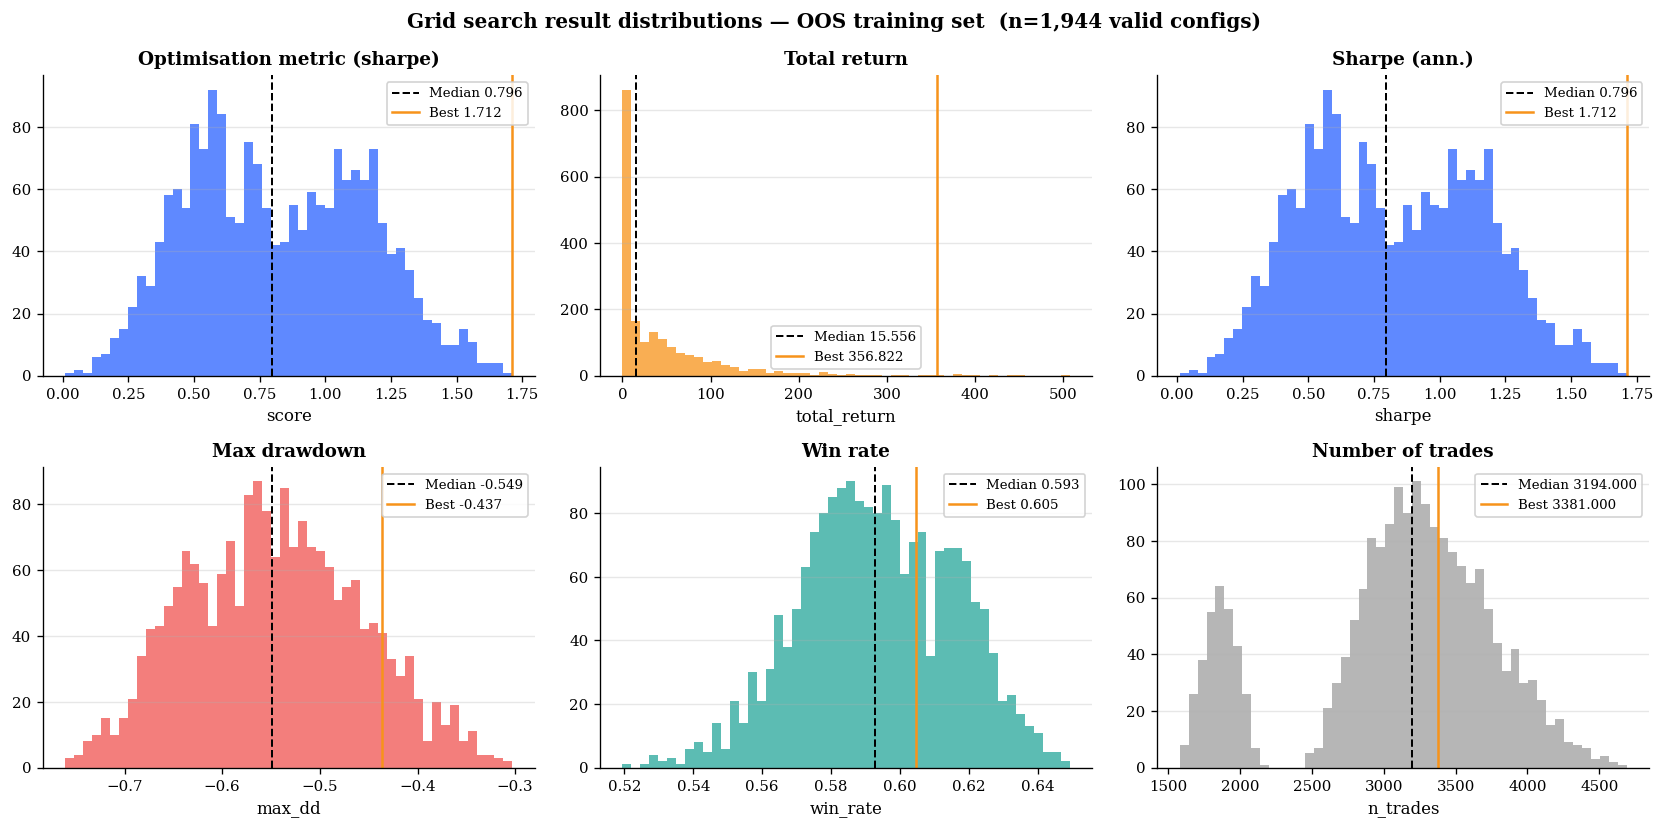

In [10]:
# ── Grid result distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

plot_cols = [
    ('score',        f'Optimisation metric ({OPTIMISE_METRIC})', BLUE),
    ('total_return', 'Total return',                              ACCENT),
    ('sharpe',       'Sharpe (ann.)',                             BLUE),
    ('max_dd',       'Max drawdown',                              RED),
    ('win_rate',     'Win rate',                                  GREEN),
    ('n_trades',     'Number of trades',                          GREY),
]

for ax, (col, title, color) in zip(axes, plot_cols):
    data = results_df[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', lw=1.2, ls='--',
               label=f'Median {data.median():.3f}')
    ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5, ls='-',
               label=f'Best {results_df[col].iloc[0]:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Grid search result distributions — OOS training set  (n={len(results_df):,} valid configs)',
    fontweight='bold', fontsize=12
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_distributions_vtrain.png')
plt.show()

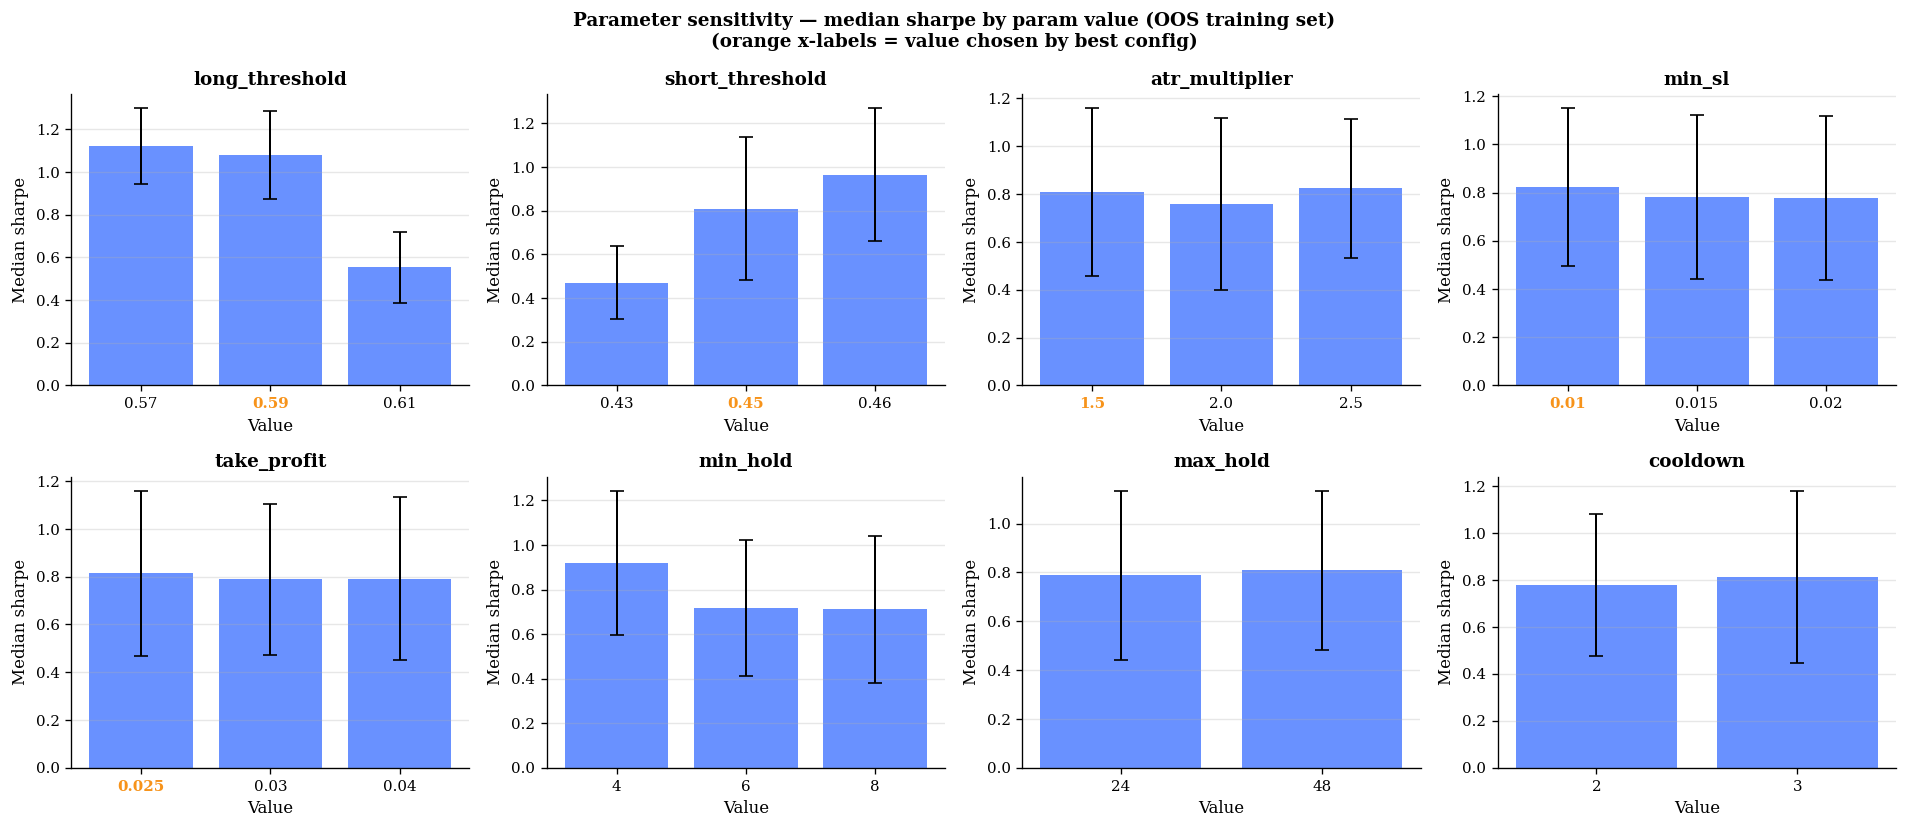

In [11]:
# ── Parameter sensitivity ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, param in zip(axes, keys):
    grp = results_df.groupby(param)['score'].agg(['median', 'mean', 'std']).reset_index()
    x   = grp[param].astype(str)
    ax.bar(x, grp['median'], color=BLUE, alpha=0.7, label='Median')
    ax.errorbar(x, grp['median'], yerr=grp['std'], fmt='none',
                color='black', capsize=4, lw=1.2)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
    ax.grid(axis='y', alpha=0.3)
    # Highlight best value
    best_val = str(best[param])
    for tick in ax.get_xticklabels():
        if tick.get_text() == best_val:
            tick.set_color(ACCENT)
            tick.set_fontweight('bold')

# Hide unused axes
for ax in axes[len(keys):]:
    ax.set_visible(False)

fig.suptitle(
    f'Parameter sensitivity — median {OPTIMISE_METRIC} by param value (OOS training set)\n'
    f'(orange x-labels = value chosen by best config)',
    fontweight='bold', fontsize=11
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_sensitivity_vtrain.png')
plt.show()

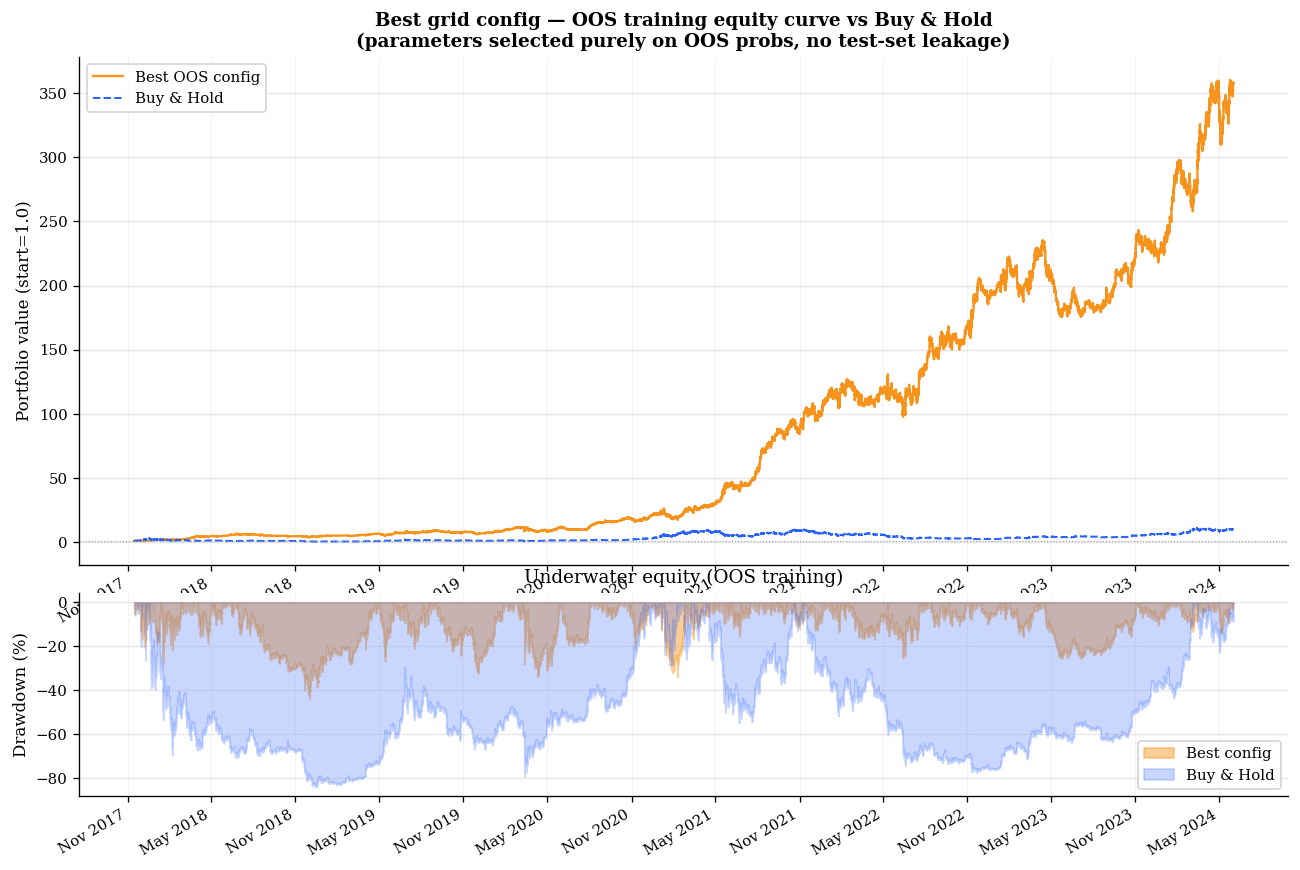

── OOS training summary (best config) ──────────────────
  Total return : +35682.22%
  B&H return   : +891.29%
  Sharpe       : 1.712
  Max DD       : -43.66%
  Trades       : 3381
  Win rate     : 60.5%


In [12]:
# ── Best config equity curve on OOS training period ───────────────────────────
eq_oos, tdf_oos = run_backtest(probs_oos, close_oos, atr_oos, index_oos, best_params)

bh_units_oos  = 1.0 / close_oos[0]
bh_equity_oos = bh_units_oos * close_oos

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

ax = axes[0]
ax.plot(index_oos, eq_oos,         color=ACCENT, lw=1.4, label='Best OOS config')
ax.plot(index_oos, bh_equity_oos,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title(
    'Best grid config — OOS training equity curve vs Buy & Hold\n'
    '(parameters selected purely on OOS probs, no test-set leakage)',
    fontweight='bold'
)
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
pk_b = np.maximum.accumulate(eq_oos)
pk_h = np.maximum.accumulate(bh_equity_oos)
ax.fill_between(index_oos, (eq_oos - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(index_oos, (bh_equity_oos - pk_h) / (pk_h + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Underwater equity (OOS training)')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_oos_best_equity_vtrain.png')
plt.show()

# Summary
pnl_oos = tdf_oos['pnl_pct']
print('── OOS training summary (best config) ──────────────────')
print(f'  Total return : {(eq_oos[-1]-1)*100:+.2f}%')
print(f'  B&H return   : {(bh_equity_oos[-1]-1)*100:+.2f}%')
print(f'  Sharpe       : {best["sharpe"]:.3f}')
print(f'  Max DD       : {best["max_dd"]*100:.2f}%')
print(f'  Trades       : {len(tdf_oos)}')
print(f'  Win rate     : {(pnl_oos > 0).mean()*100:.1f}%')

## 3. Final honest test evaluation

Apply the best OOS parameters to the test set **once** using the production model (trained on all training data).

This is the only time the test set is touched. The result reflects genuine out-of-sample performance — no parameter selection was done on test data.

In [13]:
# ── Load production model & run test inference ────────────────────────────────
prod_model = lgb.Booster(model_file=str(MODELS_DIR / 'lgbm_model.txt'))
print(f'Production model loaded — {prod_model.num_trees()} trees')

probs_test = prod_model.predict(X_test)
close_test = test_df['close'].values
atr_test   = test_df['atr_14_pct'].values
index_test = test_df.index

print(f'Test bars       : {len(probs_test):,}')
print(f'Test prob range : [{probs_test.min():.4f}, {probs_test.max():.4f}]')
print(f'\nBest OOS params:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

# Run final test backtest with best OOS params
eq_test, tdf_test = run_backtest(probs_test, close_test, atr_test, index_test, best_params)

bh_units_test  = 1.0 / close_test[0]
bh_equity_test = bh_units_test * close_test

ret_test = np.log(eq_test[1:] / (eq_test[:-1] + 1e-12))
sharpe_test = float(ret_test.mean() / (ret_test.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
pk_test = np.maximum.accumulate(eq_test)
mdd_test = float(((eq_test - pk_test) / (pk_test + 1e-12)).min())

pnl_test = tdf_test['pnl_pct'] if not tdf_test.empty else pd.Series(dtype=float)

print(f'\n── Honest test evaluation (UNSEEN data) ─────────────────')
print(f'  Period       : {index_test.min().date()} → {index_test.max().date()}')
print(f'  Total return : {(eq_test[-1]-1)*100:+.2f}%')
print(f'  B&H return   : {(bh_equity_test[-1]-1)*100:+.2f}%')
print(f'  Alpha        : {(eq_test[-1] - bh_equity_test[-1])*100:+.2f}pp')
print(f'  Sharpe (ann) : {sharpe_test:.3f}')
print(f'  Max DD       : {mdd_test*100:.2f}%')
if not tdf_test.empty:
    print(f'  Trades       : {len(tdf_test)}')
    print(f'    Long       : {(tdf_test["direction"]=="long").sum()}')
    print(f'    Short      : {(tdf_test["direction"]=="short").sum()}')
    print(f'  Win rate     : {(pnl_test > 0).mean()*100:.1f}%')
    print(f'  Avg hold (h) : {tdf_test["hold_h"].mean():.1f}')
print(f'\n  NOTE: Compare with nb-07 sharpe={best["score"]:.3f} on OOS training.')
print(f'  A large gap here signals overfitting to the original test set in nb-07.')

Production model loaded — 88 trees
Test bars       : 13,248
Test prob range : [0.3666, 0.6699]

Best OOS params:
  long_threshold        : 0.59
  short_threshold       : 0.45
  atr_multiplier        : 1.5
  min_sl                : 0.01
  take_profit           : 0.025
  min_hold              : 4.0
  max_hold              : 48.0
  cooldown              : 3.0

── Honest test evaluation (UNSEEN data) ─────────────────
  Period       : 2024-11-10 → 2026-05-16
  Total return : +9.87%
  B&H return   : +3.14%
  Alpha        : +6.73pp
  Sharpe (ann) : 0.190
  Max DD       : -25.06%
  Trades       : 748
    Long       : 225
    Short      : 523
  Win rate     : 55.7%
  Avg hold (h) : 10.2

  NOTE: Compare with nb-07 sharpe=1.712 on OOS training.
  A large gap here signals overfitting to the original test set in nb-07.


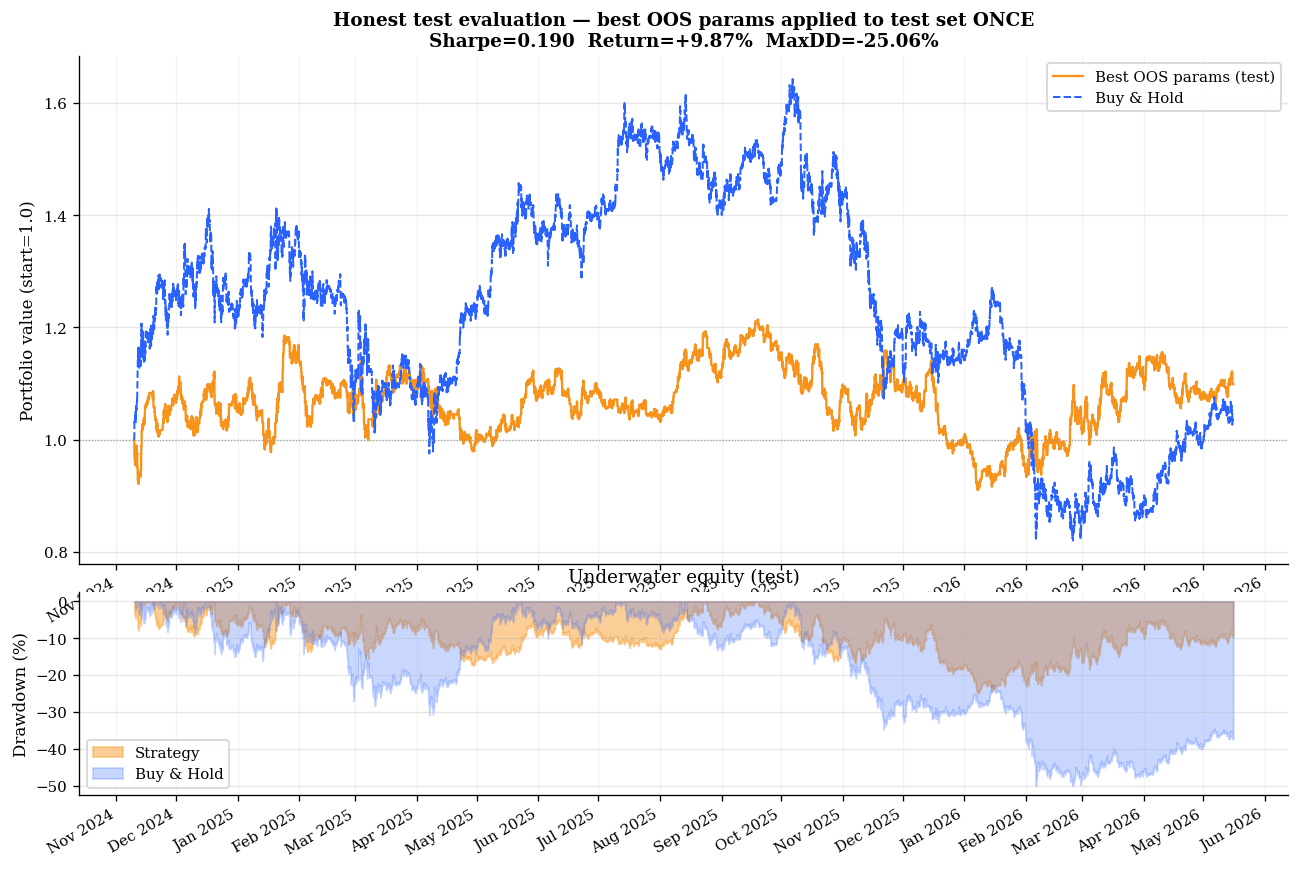

In [14]:
# ── Test equity curve ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

ax = axes[0]
ax.plot(index_test, eq_test,         color=ACCENT, lw=1.4, label='Best OOS params (test)')
ax.plot(index_test, bh_equity_test,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title(
    f'Honest test evaluation — best OOS params applied to test set ONCE\n'
    f'Sharpe={sharpe_test:.3f}  Return={eq_test[-1]-1:+.2%}  MaxDD={mdd_test:.2%}',
    fontweight='bold'
)
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
pk_b = np.maximum.accumulate(eq_test)
pk_h = np.maximum.accumulate(bh_equity_test)
ax.fill_between(index_test, (eq_test - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Strategy')
ax.fill_between(index_test, (bh_equity_test - pk_h) / (pk_h + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Underwater equity (test)')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_test_best_equity_vtrain.png')
plt.show()

In [15]:
# ── Save results ──────────────────────────────────────────────────────────────
RESULTS_PATH     = MODELS_DIR / 'lgbm_grid_results_vtrain.csv'
BEST_PARAMS_PATH = MODELS_DIR / 'lgbm_best_trading_params_vtrain.json'

results_df.to_csv(RESULTS_PATH, index=False)
print(f'Saved {len(results_df):,} grid results → {RESULTS_PATH}')

best_summary = {
    'params':               best_params,
    'oos_metric':           OPTIMISE_METRIC,
    'oos_score':            float(best['score']),
    'oos_sharpe':           float(best['sharpe']),
    'oos_total_return':     float(best['total_return']),
    'oos_max_dd':           float(best['max_dd']),
    'oos_n_trades':         int(best['n_trades']),
    'test_sharpe':          float(sharpe_test),
    'test_total_return':    float(eq_test[-1] - 1),
    'test_max_dd':          float(mdd_test),
    'test_n_trades':        int(len(tdf_test)),
    'k_folds':              K,
    'embargo_bars':         EMBARGO,
}

with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_summary, f, indent=2)
print(f'Saved best params  → {BEST_PARAMS_PATH}')

print('\n── Done ─────────────────────────────────────────────────')
print(f'  OOS Sharpe (training CV) : {best["sharpe"]:.3f}')
print(f'  Test Sharpe (honest)     : {sharpe_test:.3f}')

Saved 1,944 grid results → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain.csv
Saved best params  → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain.json

── Done ─────────────────────────────────────────────────
  OOS Sharpe (training CV) : 1.712
  Test Sharpe (honest)     : 0.190
